In [1]:
import torch
import kagglehub
from datasets import load_from_disk
from transformers import (
    WhisperFeatureExtractor,
    WhisperTokenizer,
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from dataclasses import dataclass
from typing import Any, Dict, List, Union
!pip install evaluate
!pip install jiwer
import evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 1. LOAD DATASET DARI KAGGLE
# Split sudah tersedia: train / validation / test
# Audio sudah 16kHz — tidak perlu cast
# ==========================================
print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("nalaprogroup/data-nalapro-project03")
print(f"Downloaded to: {dataset_path}")

dataset = load_from_disk(dataset_path)
print(f"Dataset loaded:\n{dataset}")

# Pisahkan split
train_data = dataset["train"]        # 1800 samples
eval_data  = dataset["validation"]   # 56 samples
test_data  = dataset["test"]         # 57 samples

Using Colab cache for faster access to the 'data-nalapro-project03' dataset.
Downloaded to: /kaggle/input/data-nalapro-project03
Dataset loaded:
DatasetDict({
    train: Dataset({
        features: ['audio', 'intent_class', 'transcription'],
        num_rows: 1800
    })
    validation: Dataset({
        features: ['audio', 'transcription', 'intent_class'],
        num_rows: 56
    })
    test: Dataset({
        features: ['audio', 'transcription', 'intent_class'],
        num_rows: 57
    })
})


In [4]:
# ==========================================
# 2. MODEL, TOKENIZER, PROCESSOR
# ==========================================
model_id = "openai/whisper-tiny"

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer  = WhisperTokenizer.from_pretrained(model_id, language="english", task="transcribe")
processor  = WhisperProcessor.from_pretrained(model_id, language="english", task="transcribe")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [5]:
# ==========================================
# 3. PREPROCESSING
# Kolom teks: 'transcription' (bukan 'sentence')
# Audio sudah 16kHz — langsung diproses
# ==========================================
def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    # Kolom teks pakai 'transcription'
    batch["labels"] = tokenizer(batch["transcription"]).input_ids
    return batch

print("Preprocessing train dataset...")
train_dataset = train_data.map(
    prepare_dataset,
    remove_columns=train_data.column_names,
    num_proc=1,
    cache_file_name="/tmp/train_cache.arrow",
)

print("Preprocessing validation dataset...")
eval_dataset = eval_data.map(
    prepare_dataset,
    remove_columns=eval_data.column_names,
    num_proc=1,
    cache_file_name="/tmp/eval_cache.arrow",
)

print("Preprocessing test dataset...")
test_dataset = test_data.map(
    prepare_dataset,
    remove_columns=test_data.column_names,
    num_proc=1,
    cache_file_name="/tmp/test_cache.arrow",
)

Preprocessing train dataset...


Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Preprocessing validation dataset...


Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Preprocessing test dataset...


Map:   0%|          | 0/57 [00:00<?, ? examples/s]

Transkrip Asli: 'brayon I recently and I just want to know if it's almost out of work I'm going north and going to be in different countries in different countries one if it's a different word'
Sampling Rate : 16000 Hz
Durasi Audio  : 42.67 detik

Dengarkan Audio:


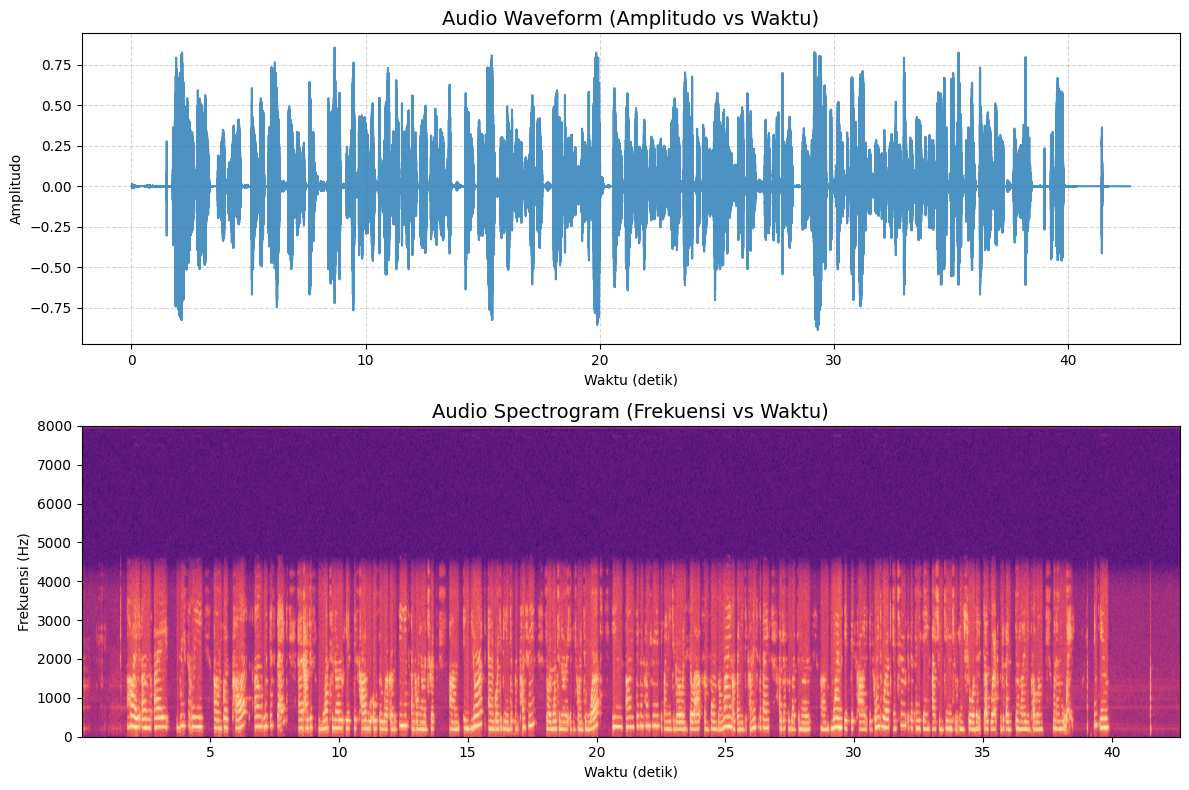

In [6]:
# ============================================
# 4. VISUALISASI SAMPLE DAN SPECTROGRAM
# ============================================
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

# Ambil satu sampel data dari 'train_data'
sample = train_data[0]

# Ekstrak array audio dan frekuensi sampling
audio_array = np.array(sample["audio"]["array"])
sampling_rate = sample["audio"]["sampling_rate"]
transcription = sample["transcription"]

print(f"Transkrip Asli: '{transcription}'")
print(f"Sampling Rate : {sampling_rate} Hz")
print(f"Durasi Audio  : {len(audio_array) / sampling_rate:.2f} detik")

# Menampilkan Audio Player
print("\nDengarkan Audio:")
display(Audio(audio_array, rate=sampling_rate))

# Visualisasi Waveform dan Spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Waveform ---
time = np.linspace(0, len(audio_array) / sampling_rate, num=len(audio_array))
axes[0].plot(time, audio_array, color="#1f77b4", alpha=0.8)
axes[0].set_title("Audio Waveform (Amplitudo vs Waktu)", fontsize=14)
axes[0].set_xlabel("Waktu (detik)")
axes[0].set_ylabel("Amplitudo")
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Spectrogram ---
axes[1].specgram(
    audio_array,
    Fs=sampling_rate,
    cmap="magma",
    NFFT=512,
    noverlap=256
)
axes[1].set_title("Audio Spectrogram (Frekuensi vs Waktu)", fontsize=14)
axes[1].set_xlabel("Waktu (detik)")
axes[1].set_ylabel("Frekuensi (Hz)")

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# 5. DATA COLLATOR
# ==========================================
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(
        self, features: List[Dict[str, Union[List[int], torch.Tensor]]]
    ) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch   = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [8]:
# ==========================================
# 6. METRIC — WER
# ==========================================
metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

In [9]:
# ==========================================
# 7. BASELINE WER (sebelum fine-tuning)
# ==========================================
print("\nMenghitung baseline WER (sebelum fine-tuning)...")
base_model = WhisperForConditionalGeneration.from_pretrained(model_id)

# Update generation config using the recommended way
base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens = []

base_trainer = Seq2SeqTrainer(
    args=Seq2SeqTrainingArguments(
        output_dir="./whisper-baseline-eval",
        per_device_eval_batch_size=8,
        predict_with_generate=True,
        generation_max_length=225,
        fp16=True,
        report_to="none",
    ),
    model=base_model,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
baseline_result = base_trainer.evaluate()
print(f"📊 Baseline WER (whisper-tiny tanpa fine-tuning): {baseline_result['eval_wer']:.2f}%")


Menghitung baseline WER (sebelum fine-tuning)...


model.safetensors:   0%|          | 0.00/151M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

📊 Baseline WER (whisper-tiny tanpa fine-tuning): 43.07%


In [10]:
# ==========================================
# 8. MODEL UNTUK FINE-TUNING
# ==========================================
model = WhisperForConditionalGeneration.from_pretrained(model_id)

# Update generation config using the recommended way
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

In [11]:
# ==========================================
# 9. TRAINING ARGUMENTS
# ==========================================
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-tiny-english",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=5e-6,
    warmup_steps=100,
    max_steps=500,
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,             # WER makin kecil makin baik
    report_to=["tensorboard"],
)

In [12]:
# ==========================================
# 10. TRAINER
# ==========================================
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [13]:
# ==========================================
# 11. TRAINING
# ==========================================
print("\nMulai fine-tuning Whisper-tiny...")
trainer.train()


Mulai fine-tuning Whisper-tiny...


Step,Training Loss,Validation Loss,Wer
100,1.257316,0.404886,27.709191
200,0.649231,0.359836,25.651578
300,0.374357,0.360906,25.377229
400,0.249544,0.375354,25.925926
500,0.224145,0.378833,25.240055


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=500, training_loss=1.1706338024139404, metrics={'train_runtime': 1346.8665, 'train_samples_per_second': 5.94, 'train_steps_per_second': 0.371, 'total_flos': 1.9616327663616e+17, 'train_loss': 1.1706338024139404, 'epoch': 4.426666666666667})

In [14]:
# ==========================================
# 12. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nEvaluasi pada test set...")
test_result = trainer.predict(test_dataset)
print(f"📊 Test WER setelah fine-tuning: {test_result.metrics['test_wer']:.2f}%")

# Ringkasan perbandingan
print("\n" + "="*50)
print("RINGKASAN HASIL")
print("="*50)
print(f"Baseline WER  : {baseline_result['eval_wer']:.2f}%")
print(f"Fine-tuned WER: {test_result.metrics['test_wer']:.2f}%")
improvement = baseline_result['eval_wer'] - test_result.metrics['test_wer']
print(f"Improvement   : {improvement:.2f}% lebih baik")
print("="*50)


Evaluasi pada test set...


📊 Test WER setelah fine-tuning: 25.13%

RINGKASAN HASIL
Baseline WER  : 43.07%
Fine-tuned WER: 25.13%
Improvement   : 17.94% lebih baik


In [15]:
# ==========================================
# 13. SAVE MODEL
# ==========================================
model.save_pretrained("./whisper-tiny-english")
processor.save_pretrained("./whisper-tiny-english")
print("\nModel tersimpan di ./whisper-tiny-english")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model tersimpan di ./whisper-tiny-english


In [16]:
# ==========================================
# 14. INFERENCE TEST
# ==========================================
from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model="./whisper-tiny-english",
)

print("\nModel siap digunakan.")
print("Contoh penggunaan:")
print('  result = pipe("path/to/audio.mp3")')
print('  print(result["text"])')

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]


Model siap digunakan.
Contoh penggunaan:
  result = pipe("path/to/audio.mp3")
  print(result["text"])


Memproses 10 sampel...

--- Tabel Perbandingan Prediksi dan Referensi ---


,Teks Referensi (Asli),Teks Prediksi (Model),Nilai WER
0,I'm trying to pay a large amount of money and ...,I'm trying to pay a large amount of money and...,0.000000
1,how do I set up a joint account,how do I set up a joint account,0.000000
2,I was hoping to set up a joint account,I was hoping to set up a joint account and he...,0.444444
3,my bills are due,My bills are due,0.250000
4,hi I'm trying to use the banking app on my pho...,Hi I'm trying to use the banking app on my ph...,0.045455
5,show me my account balance please,show me my account balance please,0.000000
6,how much money is my daily maximum amount,how much money is my daily maximum amount,0.000000
7,account balance,Account balance,0.500000
8,hi I want you to tell me my account balance un...,hi I wonder if you could show me my account ba...,0.307692
9,your mobile app isn't working,Your mobile app isn't working,0.200000


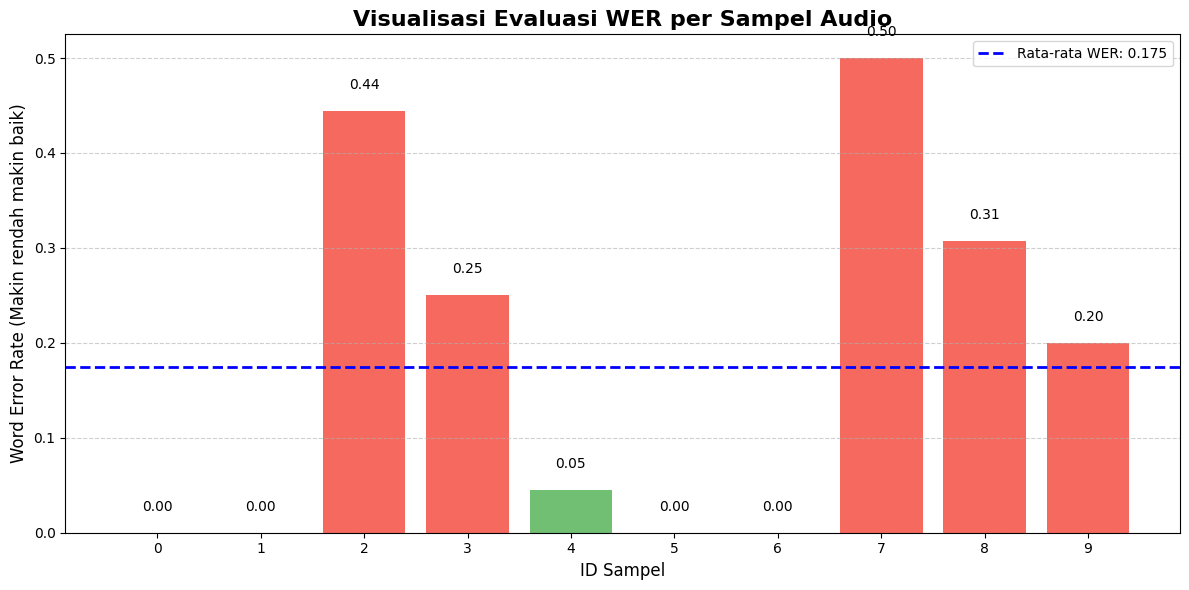

In [18]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

# Pastikan model menggunakan GPU jika tersedia untuk mempercepat proses
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load metrik WER dari library evaluate
wer_metric = evaluate.load("wer")

num_samples = 10
samples = test_dataset.select(range(num_samples))

predictions = []
references = []
wer_scores = []

print(f"Memproses {num_samples} sampel...")

# Mode evaluasi agar model tidak menghitung gradien (hemat memori)
model.eval()
with torch.no_grad():
    for i, item in enumerate(samples):
        try:
            # Siapkan input features dan pindahkan ke device (GPU/CPU)
            # Perhatikan penambahan dimensi batch dengan unsqueeze(0)
            input_features = torch.tensor(item["input_features"]).unsqueeze(0).to(device)

            # Generate prediksi menggunakan model Whisper
            predicted_ids = model.generate(input_features)
            predicted_text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

            # Decode teks asli (referensi) dari input_ids
            reference_text = tokenizer.decode(item["labels"], skip_special_tokens=True)

            # Hitung WER untuk sampel individual ini
            # WER bisa > 1.0 jika model menambahkan banyak kata ekstra (hallucination)
            score = wer_metric.compute(predictions=[predicted_text], references=[reference_text])

            predictions.append(predicted_text)
            references.append(reference_text)
            wer_scores.append(score)

        except Exception as e:
            print(f"Ups, ada sedikit error di sampel ke-{i}: {e}")
            # Lanjut ke iterasi berikutnya jika terjadi error pada satu audio
            continue

# ==========================================
# BUAT TABEL PERBANDINGAN
# ==========================================
df_results = pd.DataFrame({
    "Teks Referensi (Asli)": references,
    "Teks Prediksi (Model)": predictions,
    "Nilai WER": wer_scores
})

print("\n--- Tabel Perbandingan Prediksi dan Referensi ---")
display(df_results)

# ==========================================
# VISUALISASI GRAFIK WER PER SAMPEL
# ==========================================
plt.figure(figsize=(12, 6))

# Beri warna hijau jika WER rendah (bagus, misal < 0.2), merah jika tinggi
colors = ['#4CAF50' if w < 0.2 else '#F44336' for w in wer_scores]
bars = plt.bar(range(len(wer_scores)), wer_scores, color=colors, alpha=0.8)

# Tambahkan garis rata-rata WER
avg_wer = sum(wer_scores) / len(wer_scores)
plt.axhline(y=avg_wer, color='blue', linestyle='--', linewidth=2,
            label=f'Rata-rata WER: {avg_wer:.3f}')

# Percantik grafik
plt.title("Visualisasi Evaluasi WER per Sampel Audio", fontsize=16, fontweight='bold')
plt.xlabel("ID Sampel", fontsize=12)
plt.ylabel("Word Error Rate (Makin rendah makin baik)", fontsize=12)
plt.xticks(range(len(wer_scores)))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

# Tambahkan angka di atas setiap bar grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()